In [47]:
import numpy as np
import pandas as pd

df = pd.read_csv('../Titanic-Dataset.csv')
df.info()
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                           

Step 2: Check for Duplicate Rows

In [48]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

Step 3: Identify Column Data Types

In [49]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print(f'Categorical Columns: {cat_col}')
print(f'Numerical Columns: {num_col}')

Categorical Columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical Columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


Step 4: Count Unique Values in the Categorical Columns

In [50]:
df[cat_col].nunique()

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

Step 5: Calculate Missing Values as Percentage

In [51]:
round(df.isnull().sum() / df.shape[0] * 100 , 2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

Step 6: Drop Irrelevant or Data-Heavy Missing Columns

In [52]:
df1 = df.drop(columns=['Cabin', 'Ticket', 'Name'])
df1 = df.dropna(subset=['Embarked'], inplace=True)
df['Age'] = df['Age'].fillna(df['Age'].mean())

Step 7: Detect Outliers with Box Plot

C:\Users\HP\AppData\Local\Temp\ipykernel_17188\771342121.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['Age'] , vert=False)


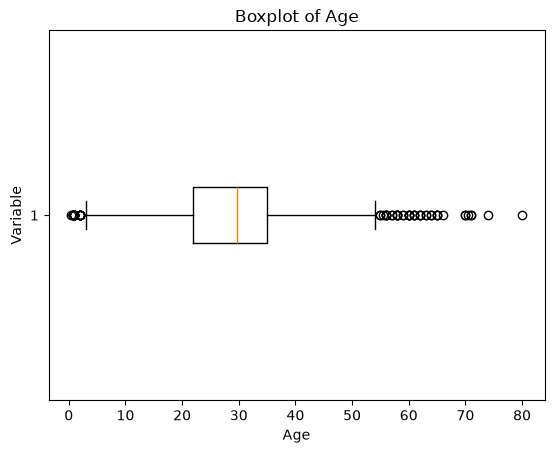

In [53]:
import matplotlib.pyplot as plt
plt.boxplot(df['Age'] , vert=False)
plt.xlabel('Age')
plt.ylabel('Variable')
plt.title('Boxplot of Age')
plt.show()

Step 8: Calculate Outlier Boundaries and Remove Them

In [54]:
mean  = df['Age'].mean()
std = df['Age'].std()
lower_limit = mean - 3 * std
upper_limit = mean + 3 * std
df2 = df[df['Age'].between(lower_limit, upper_limit)]

Step 9: Impute Missing Data Again if Any

In [55]:
df3 = df2.fillna(df2['Age'].mean())
df3.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [56]:
mean = df3['Age'].mean()
std = df3['Age'].std()

lower_limit = mean - 3 * std
upper_limit = mean + 3 * std

print(f'Lower Limit: {lower_limit}')
print(f'Upper Limit: {upper_limit}')
df4 = df3[df3['Age'].between(lower_limit, upper_limit)]

Lower Limit: -8.023949379755216
Upper Limit: 66.63011810379913


Step 11: Data validation and verification

In [57]:
X = df3[['Pclass','Sex','Age', 'SibSp','Parch','Fare','Embarked']]
Y = df3['Survived']

Step 12: Data formatting

In [58]:
X = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)
print(X.head())
print(X.dtypes)

   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  22.0      1      0   7.2500      True       False        True
1       1  38.0      1      0  71.2833     False       False       False
2       3  26.0      0      0   7.9250     False       False        True
3       1  35.0      1      0  53.1000     False       False        True
4       3  35.0      0      0   8.0500      True       False        True
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object
